In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/cleanedfix2.csv')

In [16]:

df_slight_injury = df[df["Accident_severity"] == "Slight Injury"]
df_serious_injury = df[df["Accident_severity"] == "Serious Injury"]
df_fatal_injury = df[df["Accident_severity"] == "Fatal injury"]

len(df_slight_injury), len(df_serious_injury), len(df_fatal_injury)


(10401, 1737, 158)

In [17]:
df_slight_injury["Time"] = pd.to_datetime(df_slight_injury["Time"], format="%H:%M:%S").dt.hour
df_serious_injury["Time"] = pd.to_datetime(df_serious_injury["Time"], format="%H:%M:%S").dt.hour


if not df_fatal_injury.empty:
    df_fatal_injury["Time"] = pd.to_datetime(df_fatal_injury["Time"], format="%H:%M:%S").dt.hour

/tmp/ipykernel_23506/3694940787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slight_injury["Time"] = pd.to_datetime(df_slight_injury["Time"], format="%H:%M:%S").dt.hour
/tmp/ipykernel_23506/3694940787.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_serious_injury["Time"] = pd.to_datetime(df_serious_injury["Time"], format="%H:%M:%S").dt.hour
/tmp/ipykernel_23506/3694940787.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

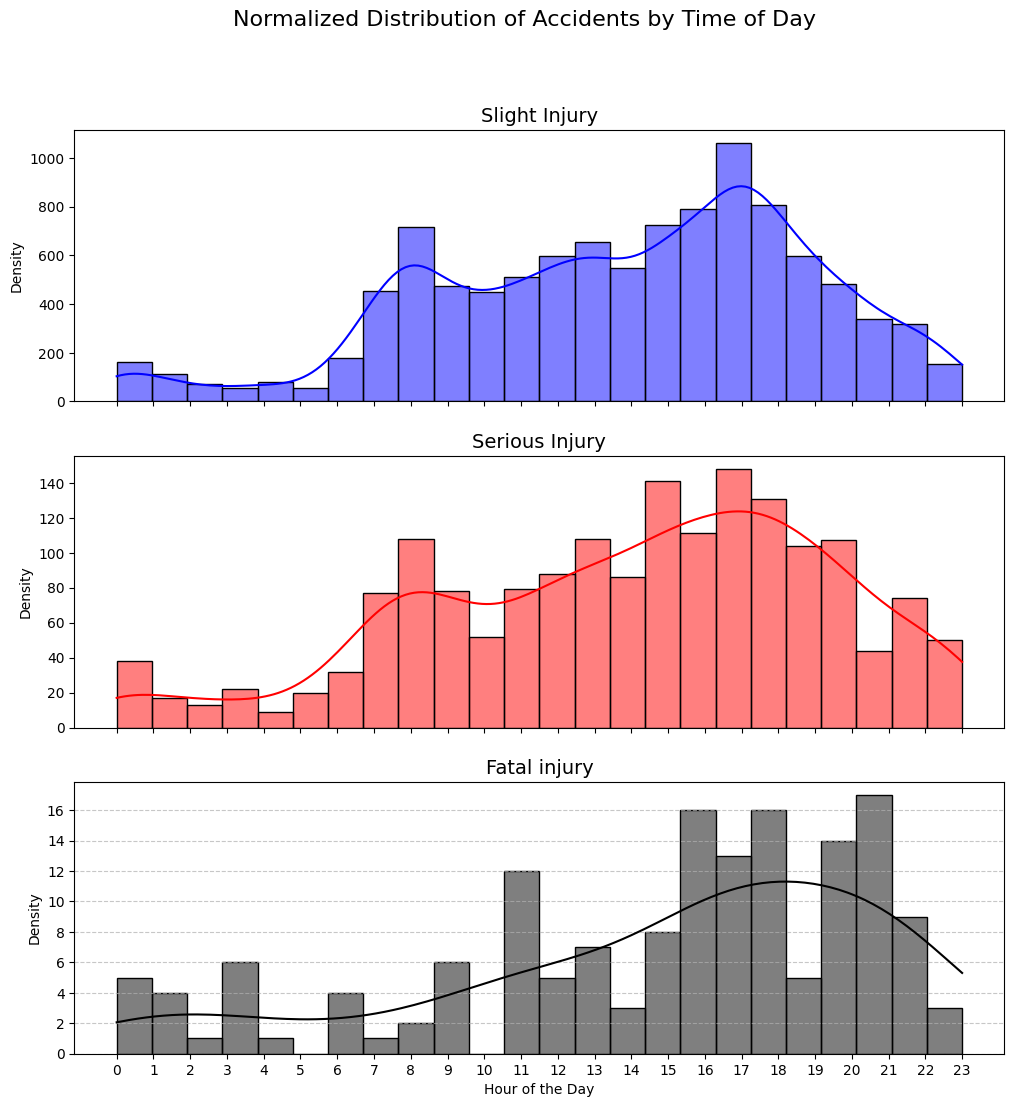

In [26]:
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Define colors for each category
colors = ["blue", "red", "black"]
titles = ["Slight Injury", "Serious Injury", "Fatal injury"]
datasets = [df_slight_injury, df_serious_injury, df_fatal_injury]

# Plot each distribution with normalization
for i, (df_subset, title, color) in enumerate(zip(datasets, titles, colors)):
    if not df_subset.empty:
        sns.histplot(df_subset["Time"], bins=24, kde=True, stat="count", color=color, ax=axes[i])
    axes[i].set_title(title, fontsize=14)
    axes[i].set_ylabel("Density")
    axes[i].set_xticks(range(24)) # Tambahkan xticks di setiap plot

axes[-1].set_xlabel("Hour of the Day")
plt.suptitle("Normalized Distribution of Accidents by Time of Day", fontsize=16)
plt.xticks(range(24)) # Tambahkan xticks di plot utama
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


/tmp/ipykernel_23506/567836685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Day", data=df, palette="viridis", order=days_order)


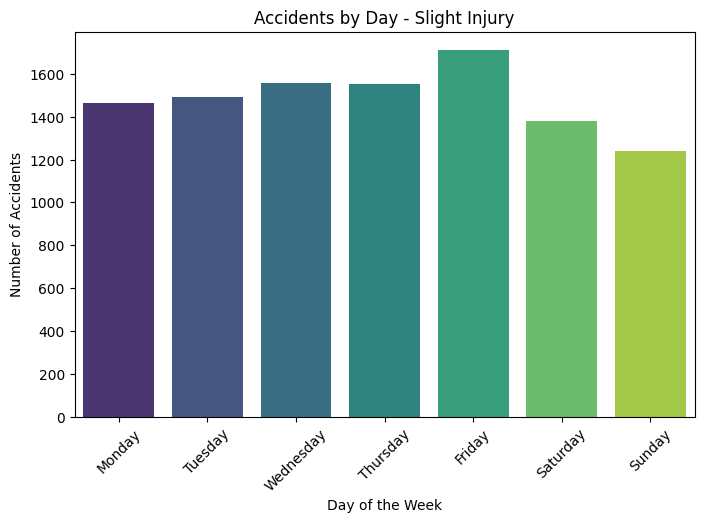

/tmp/ipykernel_23506/567836685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Day", data=df, palette="viridis", order=days_order)


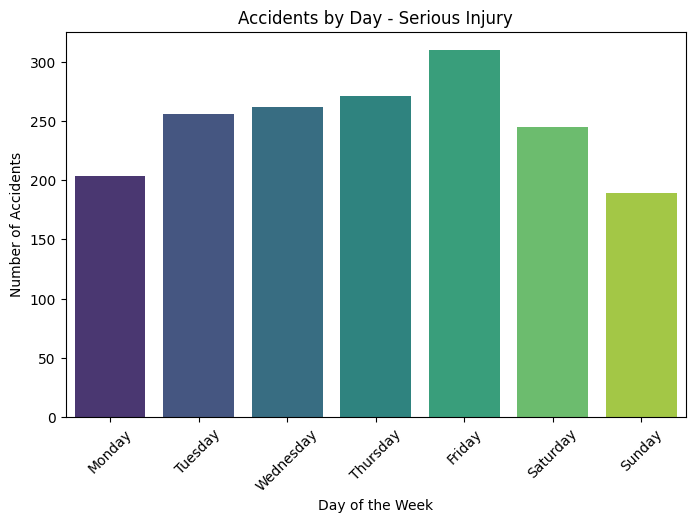

/tmp/ipykernel_23506/567836685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Day", data=df, palette="viridis", order=days_order)


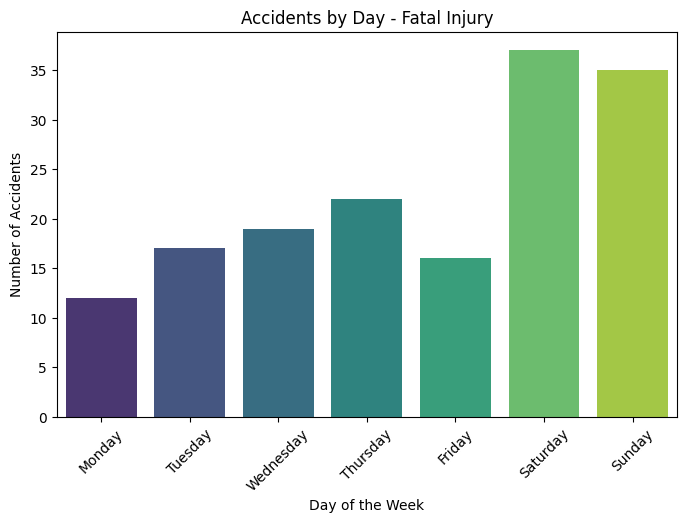

In [28]:
def plot_accidents_by_day(df, title):

    days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    plt.figure(figsize=(8, 5))
    sns.countplot(x="Day", data=df, palette="viridis", order=days_order)
    plt.title(f"Accidents by Day - {title}")
    plt.xlabel("Day of the Week")
    plt.ylabel("Number of Accidents")
    plt.xticks(rotation=45)
    plt.show()


plot_accidents_by_day(df_slight_injury, "Slight Injury")


plot_accidents_by_day(df_serious_injury, "Serious Injury")

plot_accidents_by_day(df_fatal_injury, "Fatal Injury")

/tmp/ipykernel_23506/1772951802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_vehicles_involved"], palette="magma")


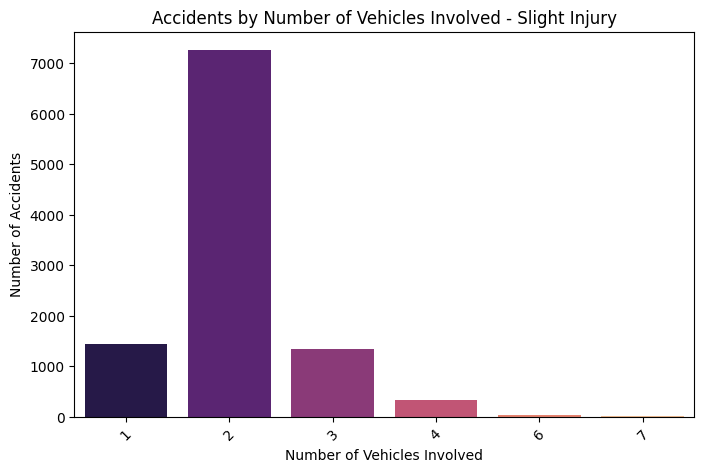

/tmp/ipykernel_23506/1772951802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_vehicles_involved"], palette="magma")


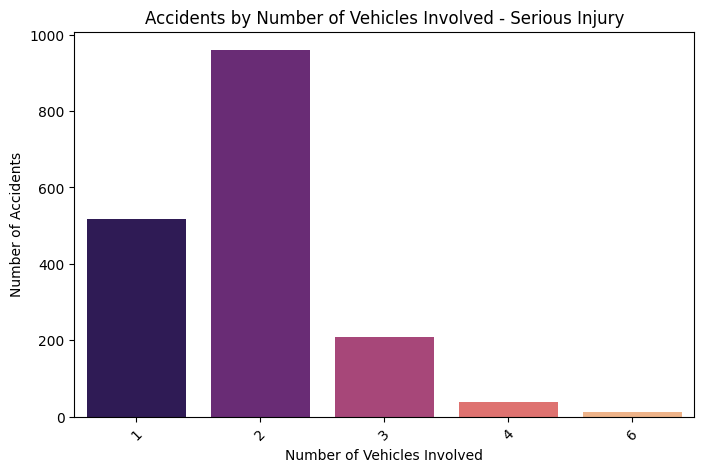

/tmp/ipykernel_23506/1772951802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_vehicles_involved"], palette="magma")


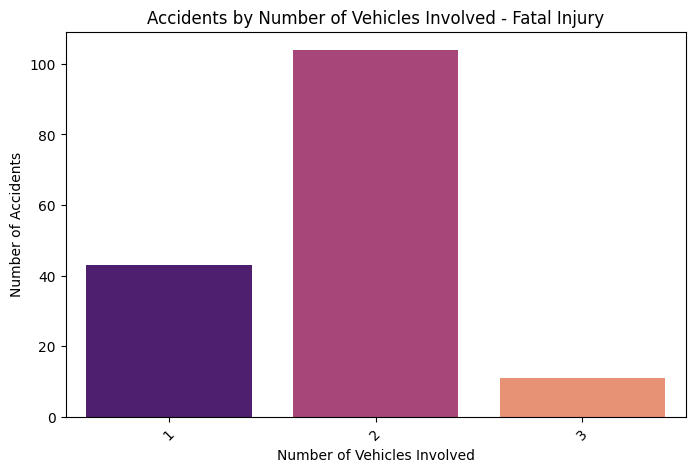

In [29]:
# Fungsi untuk membuat plot hubungan jumlah kendaraan yang terlibat dengan jumlah kecelakaan
def plot_accidents_by_vehicles(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df["Number_of_vehicles_involved"], palette="magma")
    plt.title(f"Accidents by Number of Vehicles Involved - {title}")
    plt.xlabel("Number of Vehicles Involved")
    plt.ylabel("Number of Accidents")
    plt.xticks(rotation=45)
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_vehicles(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_vehicles(df_serious_injury, "Serious Injury")
plot_accidents_by_vehicles(df_fatal_injury, "Fatal Injury")



/tmp/ipykernel_23506/1013121481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_casualties"], palette="magma")


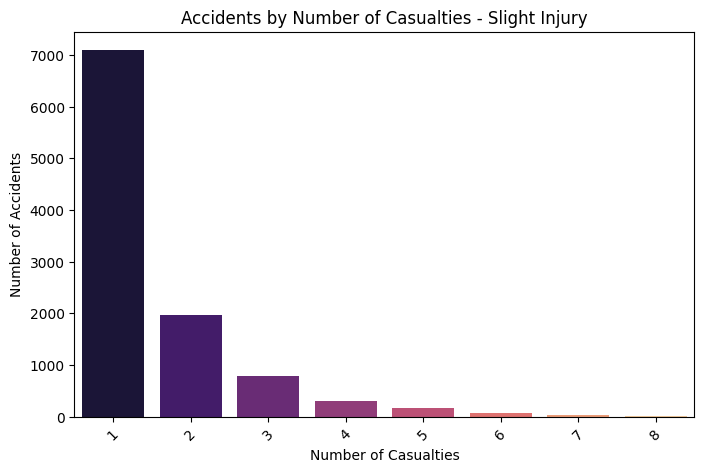

/tmp/ipykernel_23506/1013121481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_casualties"], palette="magma")


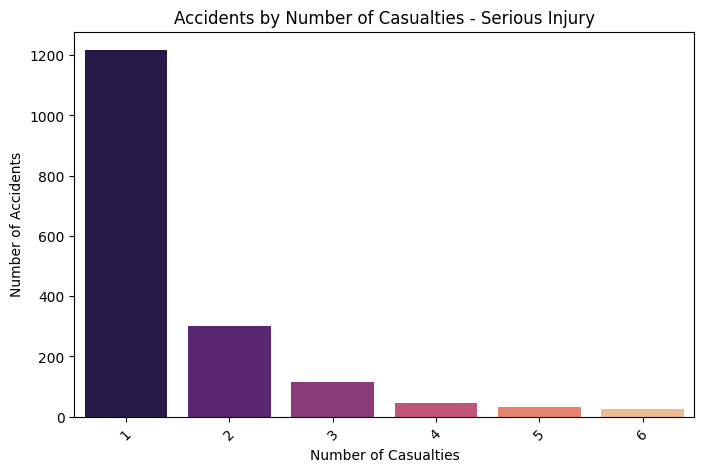

/tmp/ipykernel_23506/1013121481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Number_of_casualties"], palette="magma")


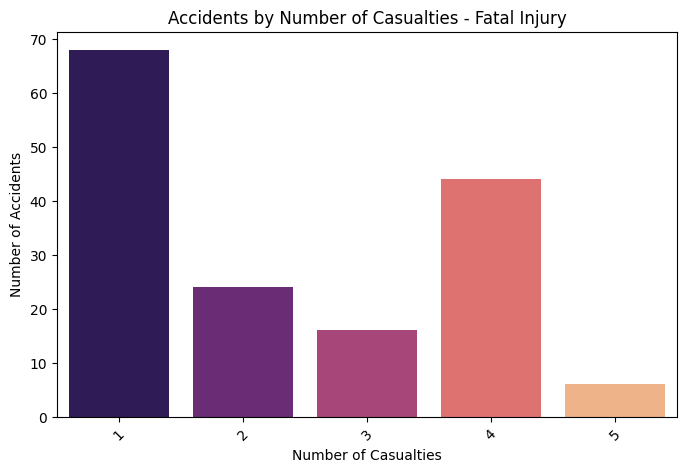

In [30]:
# Fungsi untuk membuat plot hubungan jumlah korban dengan jumlah kecelakaan
def plot_accidents_by_casualties(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df["Number_of_casualties"], palette="magma")
    plt.title(f"Accidents by Number of Casualties - {title}")
    plt.xlabel("Number of Casualties")
    plt.ylabel("Number of Accidents")
    plt.xticks(rotation=45)
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_casualties(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_casualties(df_serious_injury, "Serious Injury")


plot_accidents_by_casualties(df_fatal_injury, "Fatal Injury")



/tmp/ipykernel_23506/4109890423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Age_band_of_driver"], palette="magma", order=df["Age_band_of_driver"].value_counts().index)


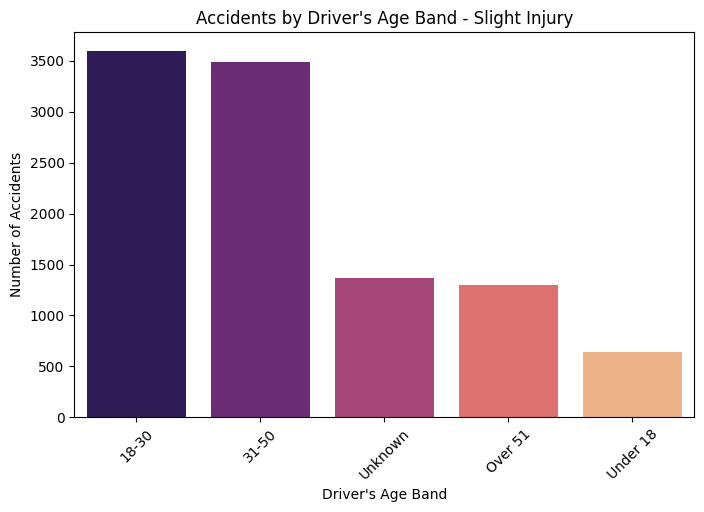

/tmp/ipykernel_23506/4109890423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Age_band_of_driver"], palette="magma", order=df["Age_band_of_driver"].value_counts().index)


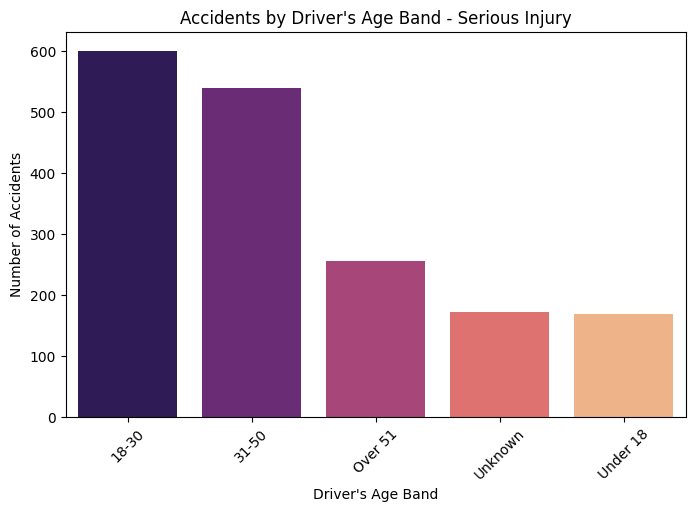

/tmp/ipykernel_23506/4109890423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Age_band_of_driver"], palette="magma", order=df["Age_band_of_driver"].value_counts().index)


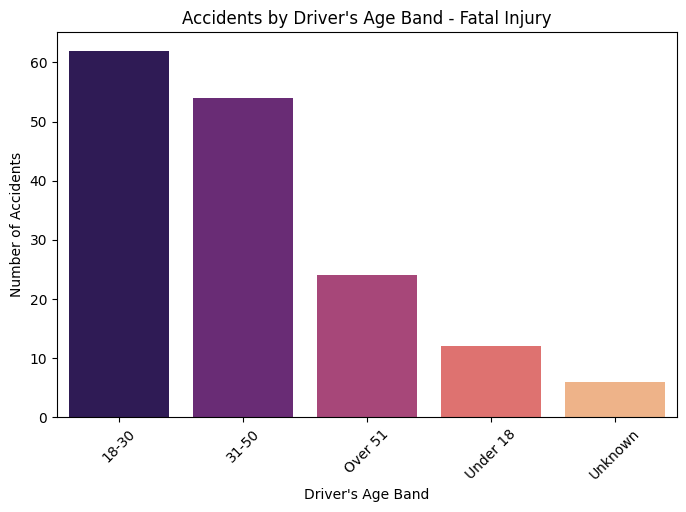

In [32]:
# Fungsi untuk membuat plot hubungan rentang usia pengemudi dengan jumlah kecelakaan
def plot_accidents_by_age(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df["Age_band_of_driver"], palette="magma", order=df["Age_band_of_driver"].value_counts().index)
    plt.title(f"Accidents by Driver's Age Band - {title}")
    plt.xlabel("Driver's Age Band")
    plt.ylabel("Number of Accidents")
    plt.xticks(rotation=45)
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_age(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_age(df_serious_injury, "Serious Injury")


plot_accidents_by_age(df_fatal_injury, "Fatal Injury")



/tmp/ipykernel_23506/2620439738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Cause_of_accident"], palette="coolwarm", order=df["Cause_of_accident"].value_counts().index[:10])


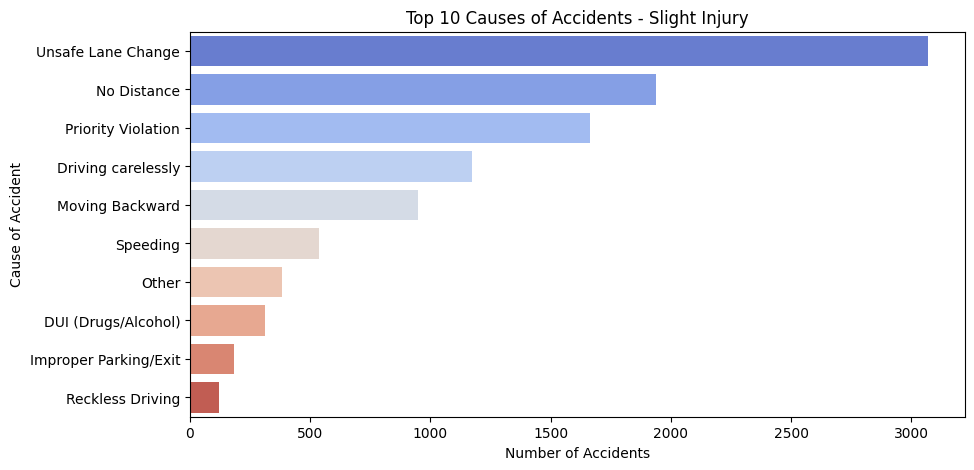

/tmp/ipykernel_23506/2620439738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Cause_of_accident"], palette="coolwarm", order=df["Cause_of_accident"].value_counts().index[:10])


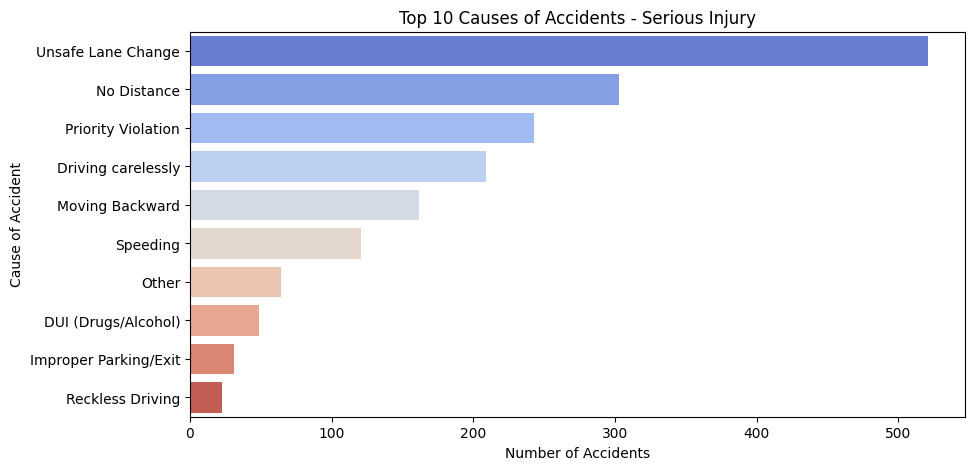

/tmp/ipykernel_23506/2620439738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Cause_of_accident"], palette="coolwarm", order=df["Cause_of_accident"].value_counts().index[:10])


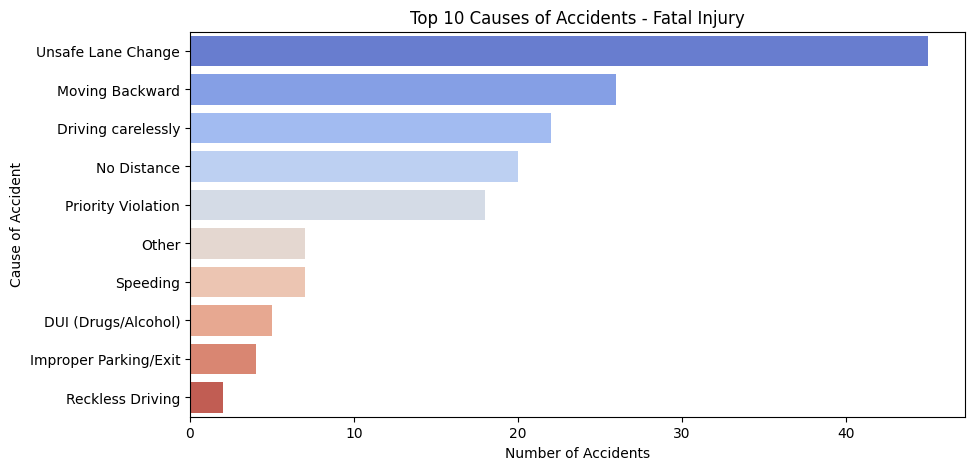

In [33]:
# Fungsi untuk membuat plot hubungan penyebab kecelakaan dengan jumlah kecelakaan
def plot_accidents_by_cause(df, title):
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df["Cause_of_accident"], palette="coolwarm", order=df["Cause_of_accident"].value_counts().index[:10])
    plt.title(f"Top 10 Causes of Accidents - {title}")
    plt.xlabel("Number of Accidents")
    plt.ylabel("Cause of Accident")
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_cause(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_cause(df_serious_injury, "Serious Injury")


plot_accidents_by_cause(df_fatal_injury, "Fatal Injury")



/tmp/ipykernel_23506/3014071213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Driving_experience"], palette="magma", order=df["Driving_experience"].value_counts().index[:10])


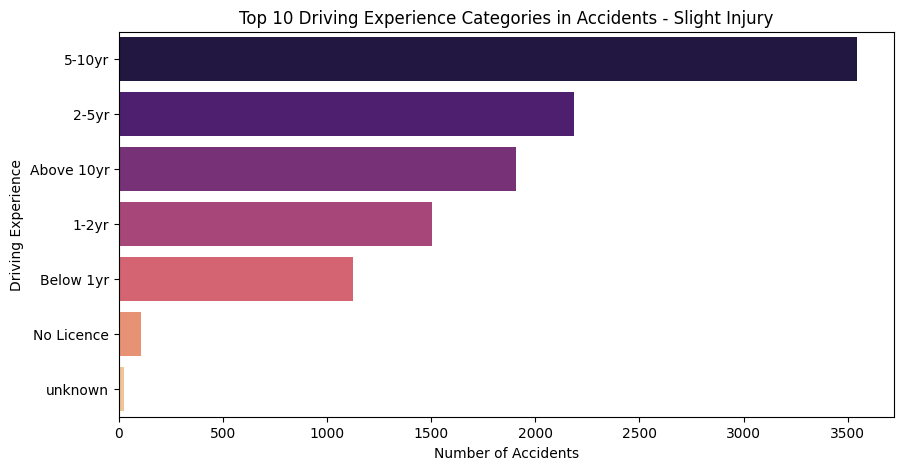

/tmp/ipykernel_23506/3014071213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Driving_experience"], palette="magma", order=df["Driving_experience"].value_counts().index[:10])


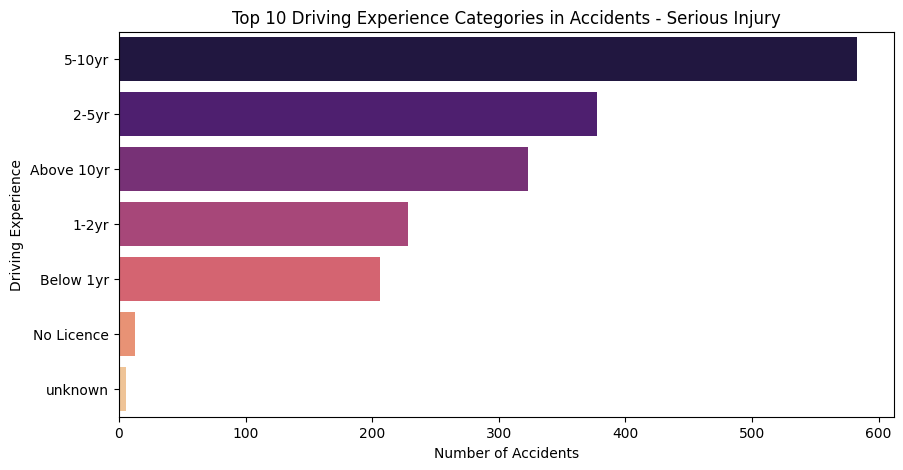

/tmp/ipykernel_23506/3014071213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Driving_experience"], palette="magma", order=df["Driving_experience"].value_counts().index[:10])


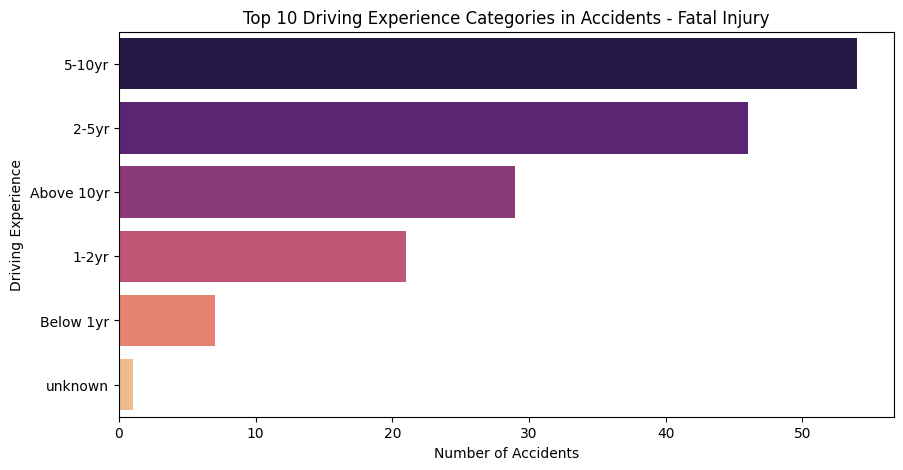

In [34]:
# Fungsi untuk membuat plot hubungan pengalaman mengemudi dengan jumlah kecelakaan
def plot_accidents_by_experience(df, title):
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df["Driving_experience"], palette="magma", order=df["Driving_experience"].value_counts().index[:10])
    plt.title(f"Top 10 Driving Experience Categories in Accidents - {title}")
    plt.xlabel("Number of Accidents")
    plt.ylabel("Driving Experience")
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_experience(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_experience(df_serious_injury, "Serious Injury")

# Plot untuk Fatal Injury (jika ada data)
if not df_fatal_injury.empty:
    plot_accidents_by_experience(df_fatal_injury, "Fatal Injury")
else:
    print("Tidak ada data untuk Fatal Injury.")




/tmp/ipykernel_23506/453533117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Area_accident_occured"], palette="magma", order=df["Area_accident_occured"].value_counts().index[:10])


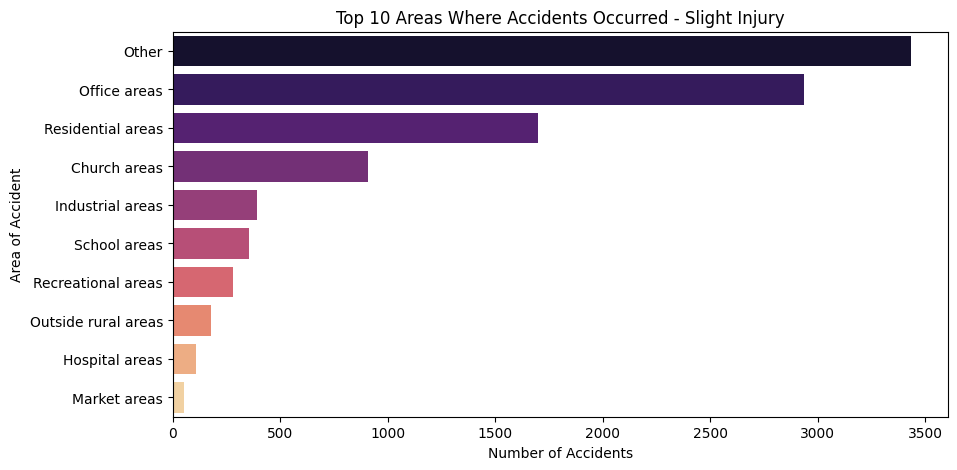

/tmp/ipykernel_23506/453533117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Area_accident_occured"], palette="magma", order=df["Area_accident_occured"].value_counts().index[:10])


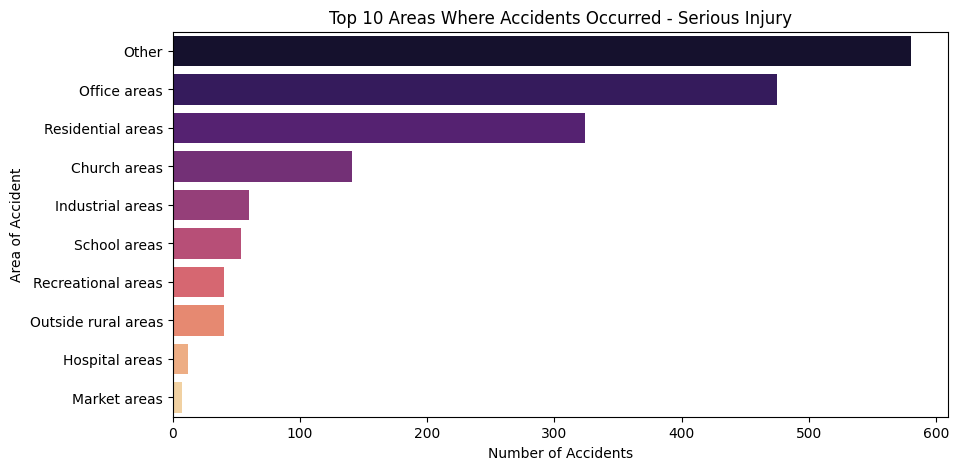

/tmp/ipykernel_23506/453533117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Area_accident_occured"], palette="magma", order=df["Area_accident_occured"].value_counts().index[:10])


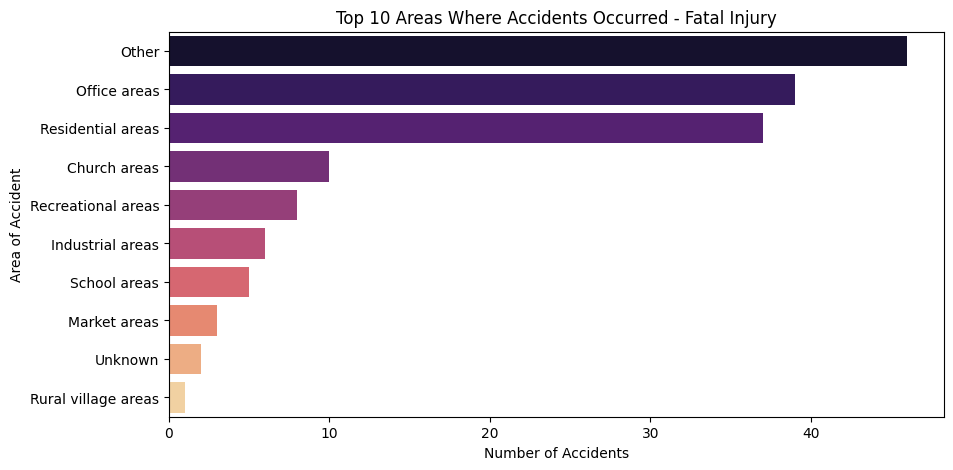

In [36]:
# Fungsi untuk membuat plot hubungan area kecelakaan dengan jumlah kecelakaan
def plot_accidents_by_area(df, title):
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df["Area_accident_occured"], palette="magma", order=df["Area_accident_occured"].value_counts().index[:10])
    plt.title(f"Top 10 Areas Where Accidents Occurred - {title}")
    plt.xlabel("Number of Accidents")
    plt.ylabel("Area of Accident")
    plt.show()

# Plot untuk Slight Injury
plot_accidents_by_area(df_slight_injury, "Slight Injury")

# Plot untuk Serious Injury
plot_accidents_by_area(df_serious_injury, "Serious Injury")

# Plot untuk Fatal Injury (jika ada data)
if not df_fatal_injury.empty:
    plot_accidents_by_area(df_fatal_injury, "Fatal Injury")
else:
    print("Tidak ada data untuk Fatal Injury.")

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


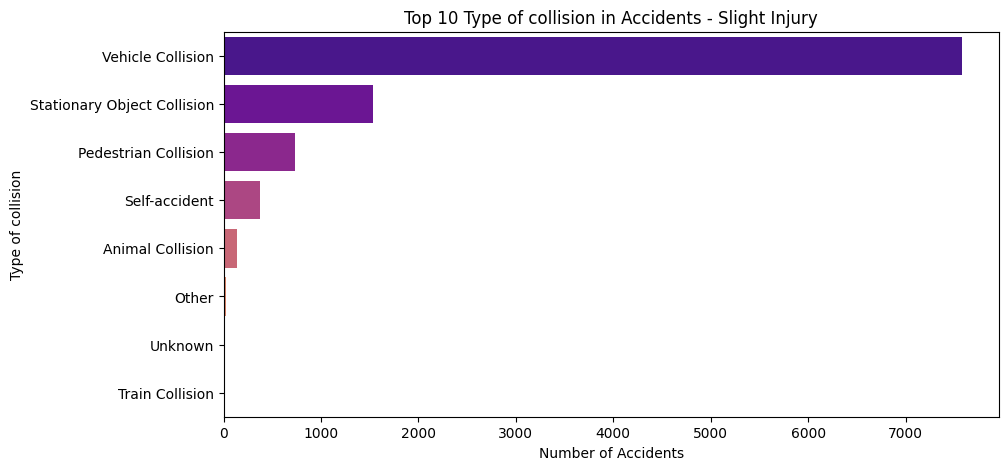

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


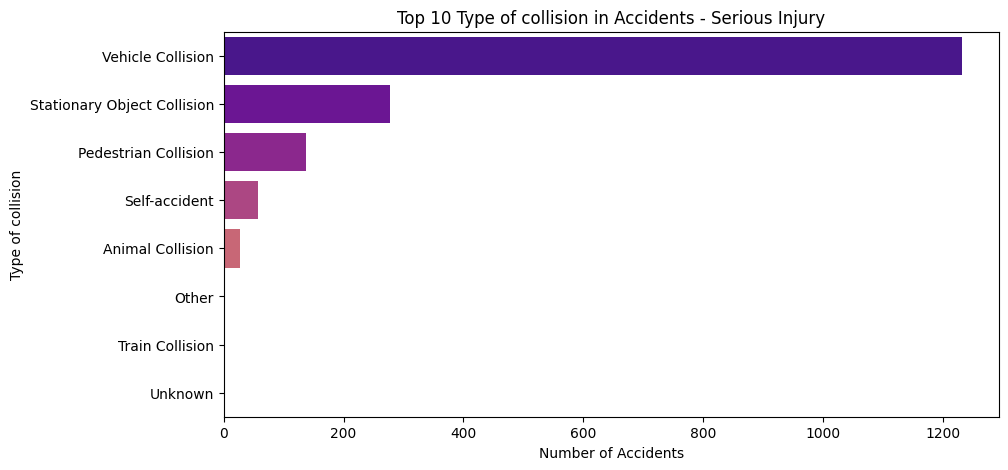

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


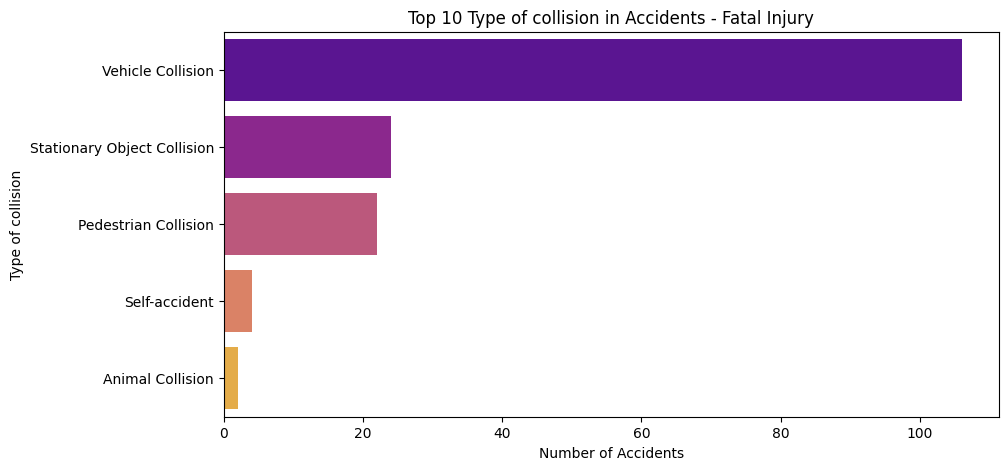

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


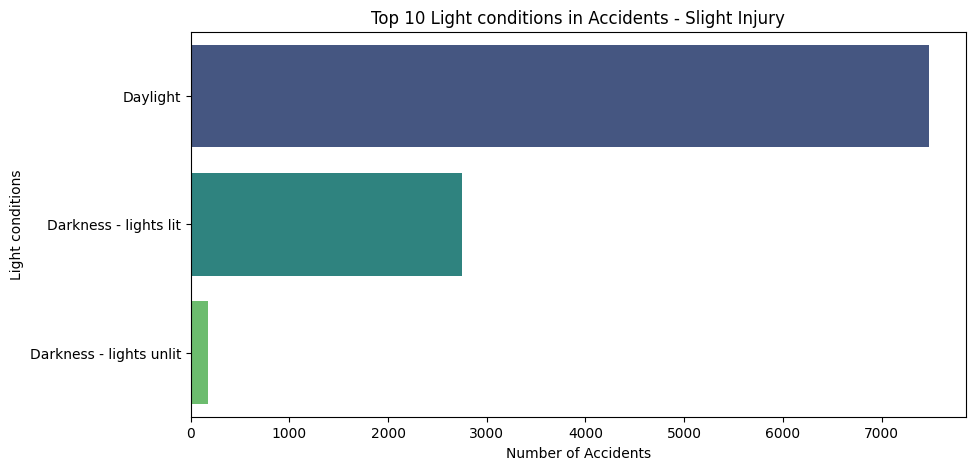

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


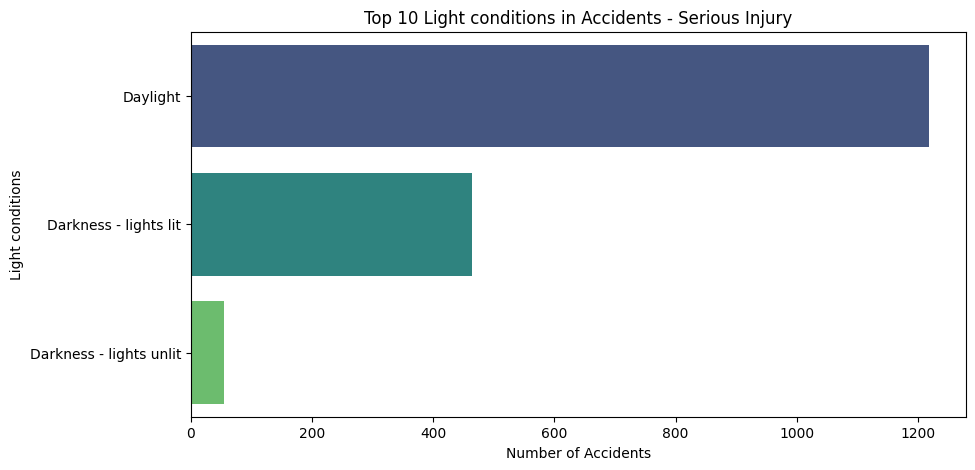

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


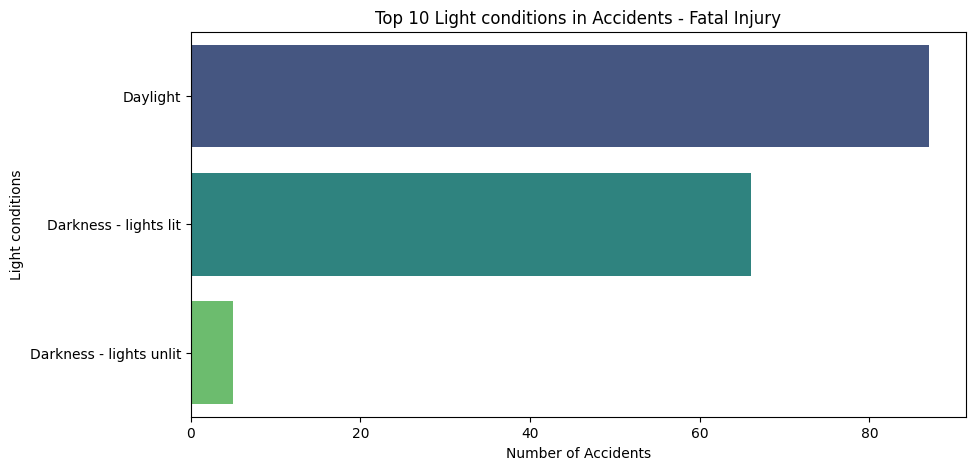

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


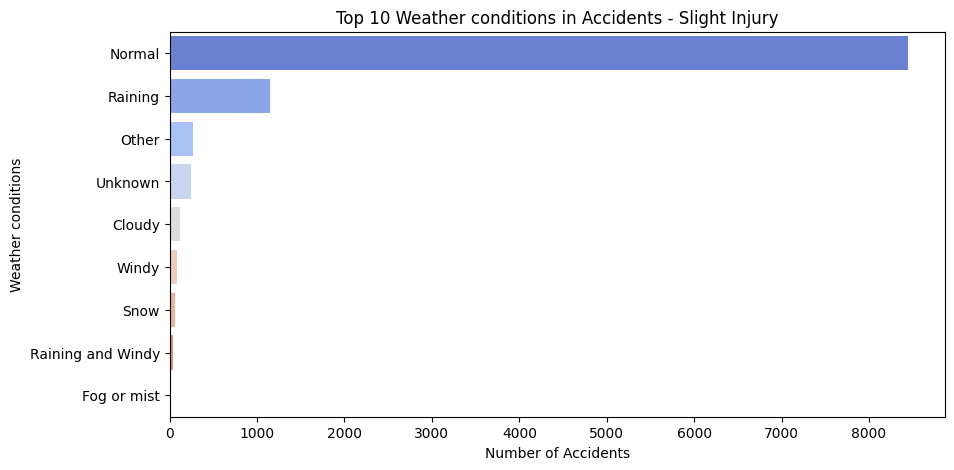

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


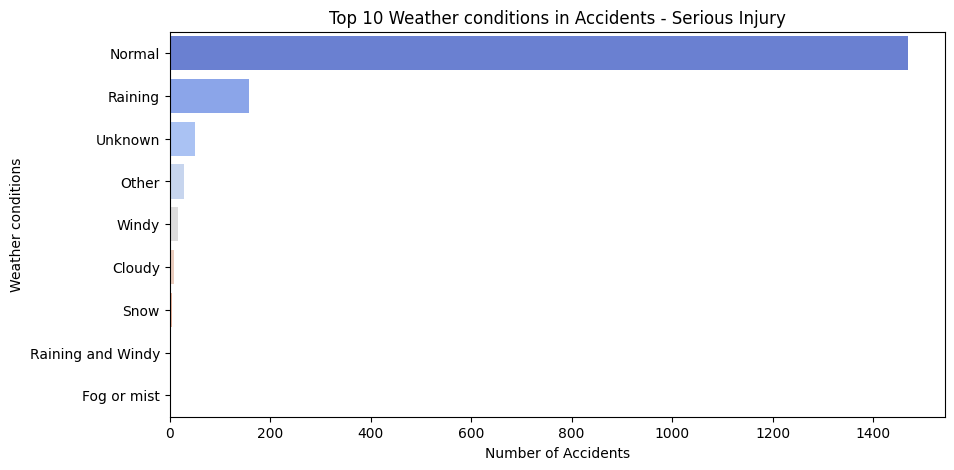

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


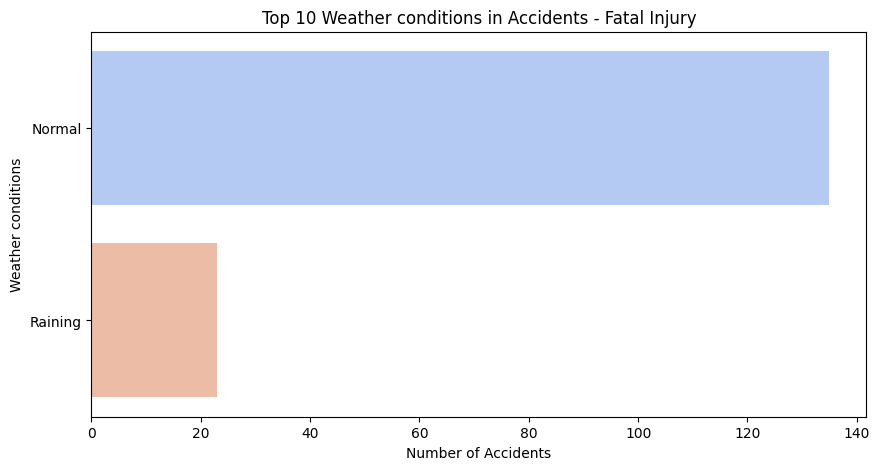

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


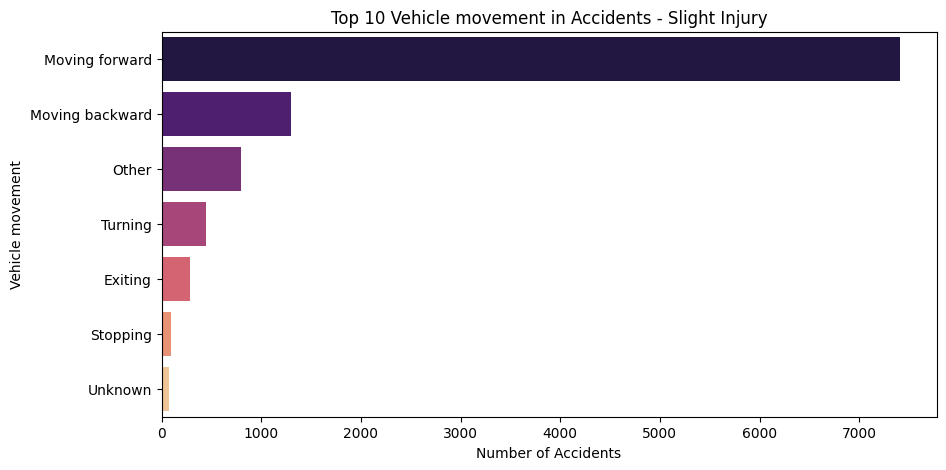

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


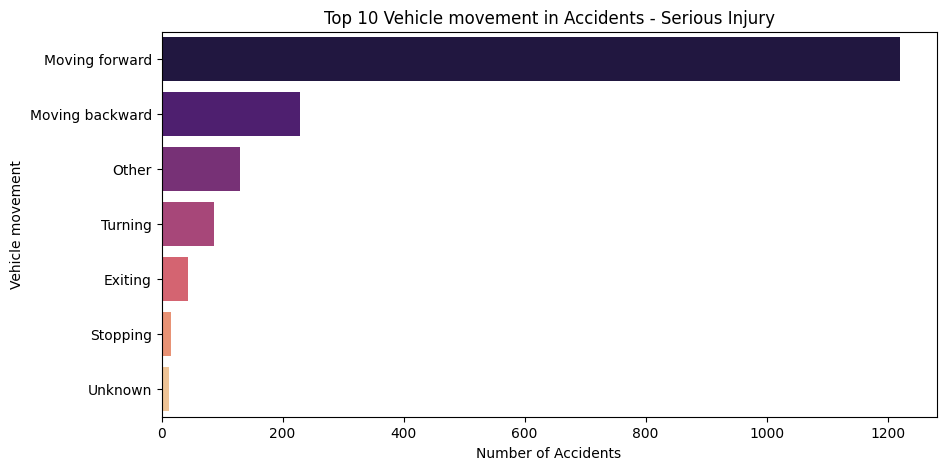

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


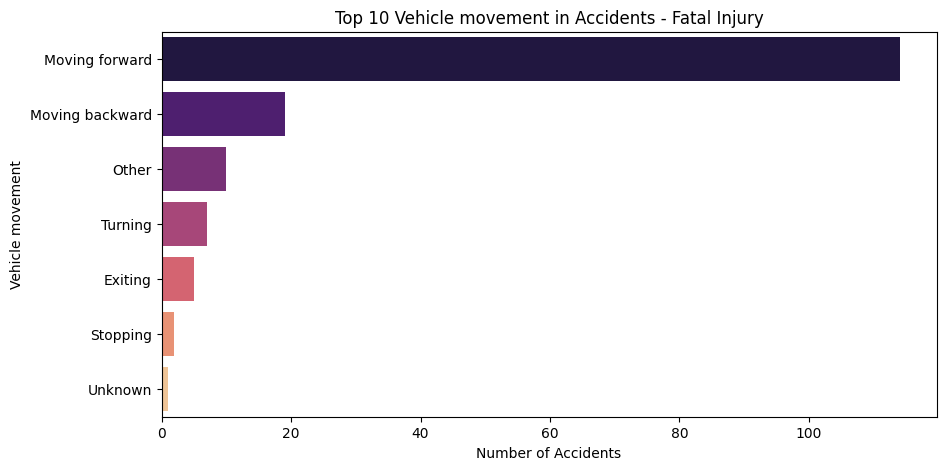

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


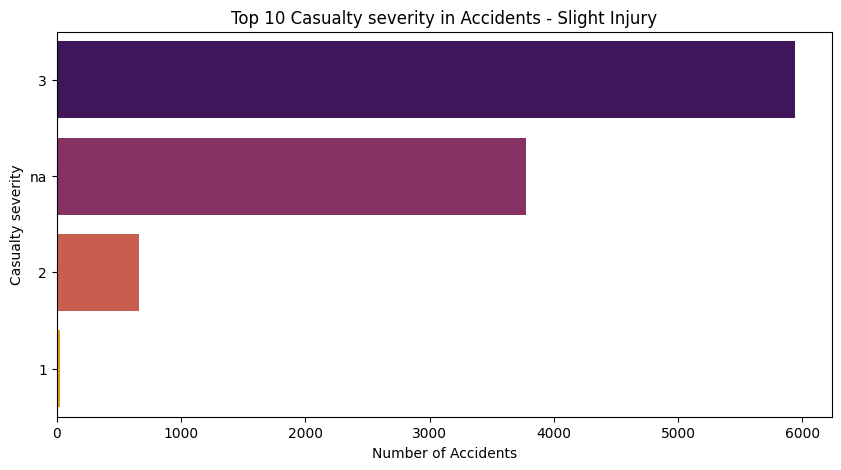

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


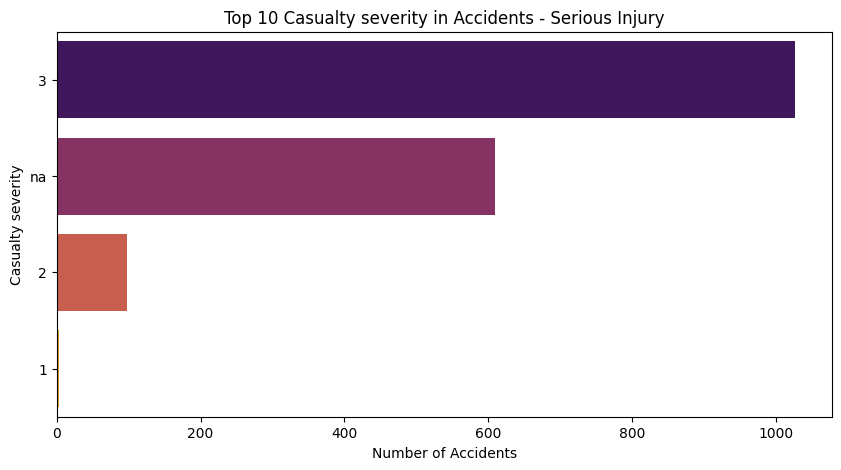

/tmp/ipykernel_23506/809852508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])


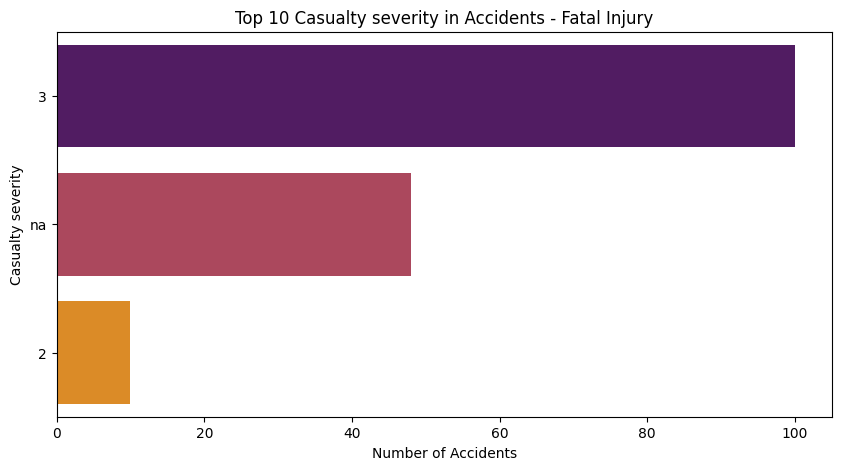

In [37]:
# Fungsi untuk membuat plot hubungan kategori tertentu dengan jumlah kecelakaan
def plot_accidents_by_category(df, column, title, palette="plasma"):
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df[column], palette=palette, order=df[column].value_counts().index[:10])
    plt.title(f"Top 10 {column.replace('_', ' ')} in Accidents - {title}")
    plt.xlabel("Number of Accidents")
    plt.ylabel(column.replace('_', ' '))
    plt.show()

# Plot untuk Type of Collision
plot_accidents_by_category(df_slight_injury, "Type_of_collision", "Slight Injury")
plot_accidents_by_category(df_serious_injury, "Type_of_collision", "Serious Injury")
if not df_fatal_injury.empty:
    plot_accidents_by_category(df_fatal_injury, "Type_of_collision", "Fatal Injury")
else:
    print("Tidak ada data untuk Fatal Injury.")

# Plot untuk Light Conditions
plot_accidents_by_category(df_slight_injury, "Light_conditions", "Slight Injury", "viridis")
plot_accidents_by_category(df_serious_injury, "Light_conditions", "Serious Injury", "viridis")
if not df_fatal_injury.empty:
    plot_accidents_by_category(df_fatal_injury, "Light_conditions", "Fatal Injury", "viridis")
else:
    print("Tidak ada data untuk Fatal Injury.")

# Plot untuk Weather Conditions
plot_accidents_by_category(df_slight_injury, "Weather_conditions", "Slight Injury", "coolwarm")
plot_accidents_by_category(df_serious_injury, "Weather_conditions", "Serious Injury", "coolwarm")
if not df_fatal_injury.empty:
    plot_accidents_by_category(df_fatal_injury, "Weather_conditions", "Fatal Injury", "coolwarm")
else:
    print("Tidak ada data untuk Fatal Injury.")

# Plot untuk Vehicle Movement
plot_accidents_by_category(df_slight_injury, "Vehicle_movement", "Slight Injury", "magma")
plot_accidents_by_category(df_serious_injury, "Vehicle_movement", "Serious Injury", "magma")
if not df_fatal_injury.empty:
    plot_accidents_by_category(df_fatal_injury, "Vehicle_movement", "Fatal Injury", "magma")
else:
    print("Tidak ada data untuk Fatal Injury.")

# Plot untuk Casualty Severity
plot_accidents_by_category(df_slight_injury, "Casualty_severity", "Slight Injury", "inferno")
plot_accidents_by_category(df_serious_injury, "Casualty_severity", "Serious Injury", "inferno")
if not df_fatal_injury.empty:
    plot_accidents_by_category(df_fatal_injury, "Casualty_severity", "Fatal Injury", "inferno")
else:
    print("Tidak ada data untuk Fatal Injury.")
